#Logistic Regression (Loan Approval Prediction)

Q1. Data Loading & Understanding

a) Load the dataset into Python.

b) Display the first 5 rows.

c) Check the shape of the dataset.

d) Display the data types of each column.

In [58]:
# Data Loading & Understanding

# Import required libraries
import pandas as pd
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Automatically get the uploaded file name
file_name = next(iter(uploaded))

# Load the dataset
df = pd.read_csv('loan_approval.csv')

print("Dataset loaded successfully!")

Saving loan_approval.csv to loan_approval (1).csv
Dataset loaded successfully!


In [59]:
# a) Load dataset and
# b) Display the first 5 rows

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [60]:
# c) Check the shape of the dataset

print("Shape of the dataset:", df.shape)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of the dataset: (2000, 8)
Number of rows: 2000
Number of columns: 8


In [61]:
# d) Display the data types of each column

print("Data Types of Each Column:")
print(df.dtypes)

Data Types of Each Column:
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


In [62]:
# Display complete dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


Q2. Data Cleaning

a) Check for missing values in the dataset.

b) Handle missing values appropriately.

c) Identify categorical columns present in the dataset.

In [63]:
# Q2 (a) Check for missing values

print("Missing Values in Each Column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

Total Missing Values: 0


In [64]:
# Display only columns containing missing values

missing_values = df.isnull().sum()

print("Columns with Missing Values:")
print(missing_values[missing_values > 0])

Columns with Missing Values:
Series([], dtype: int64)


In [65]:
# Identify numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Fill missing numerical values with median
for column in numerical_cols:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with mode
for column in categorical_cols:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [66]:
# Check missing values again

print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nTotal Missing Values After Cleaning:",
      df.isnull().sum().sum())

Missing Values After Cleaning:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

Total Missing Values After Cleaning: 0


In [67]:
# Q2 (c) Identify categorical columns

categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumber of Categorical Columns:",
      len(categorical_cols))

Categorical Columns:
['name', 'city']

Number of Categorical Columns: 2


In [68]:
# Display unique values in categorical columns

for column in categorical_cols:
    print(f"\n{column}:")
    print(df[column].unique())


name:
['Allison Hill' 'Brandon Hall' 'Rhonda Smith' ... 'Brandon Meyer'
 'Jason Price' 'Nicole Brown']

city:
['East Jill' 'New Jamesside' 'Lake Roberto' ... 'East Haley' 'Adamland'
 'New Nathantown']


Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.

b) Analyze the relationship between one numerical feature and the target variable.

c) Analyze the relationship between Years of Employment and the target variable.

In [69]:
# Check all column names

print("Columns in the Dataset:")
print(df.columns.tolist())

Columns in the Dataset:
['name', 'city', 'income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved']


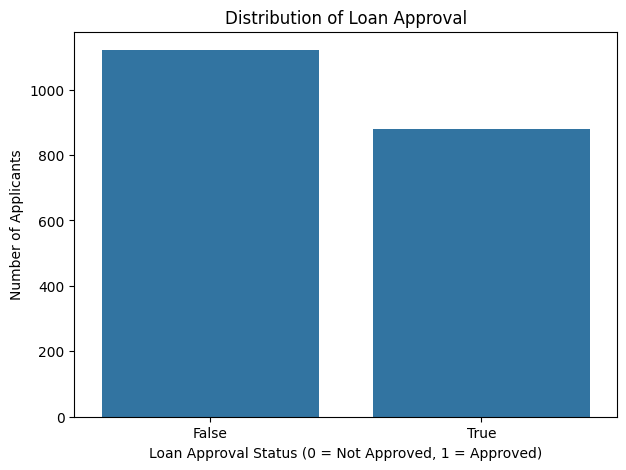

Loan Approval Counts:
loan_approved
False    1121
True      879
Name: count, dtype: int64

Loan Approval Percentage:
loan_approved
False    56.05
True     43.95
Name: proportion, dtype: float64


In [70]:
#Target Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Set target column
target = 'loan_approved'   # Change if your target column has a different name

# Countplot of target variable
plt.figure(figsize=(7, 5))

sns.countplot(x=target, data=df)

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approval Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("Number of Applicants")

plt.show()

# Display counts
print("Loan Approval Counts:")
print(df[target].value_counts())

# Display percentages
print("\nLoan Approval Percentage:")
print(df[target].value_counts(normalize=True) * 100)

In [71]:
# Display numerical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points']


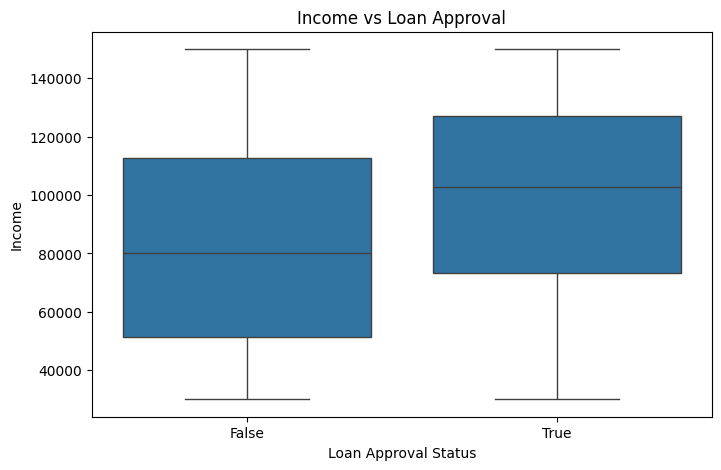

In [72]:
# Relationship between Income and Loan Approval

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=target,
    y='income',
    data=df
)

plt.title("Income vs Loan Approval")
plt.xlabel("Loan Approval Status")
plt.ylabel("Income")

plt.show()

In [73]:
# Average income according to loan approval status

income_analysis = df.groupby(target)['income'].agg(
    ['count', 'mean', 'median']
)

print("Income Analysis by Loan Approval Status:")
display(income_analysis)

Income Analysis by Loan Approval Status:


,count,mean,median
loan_approved,,,
False,1121,83317.456735,80140.0
True,879,99855.614334,102768.0


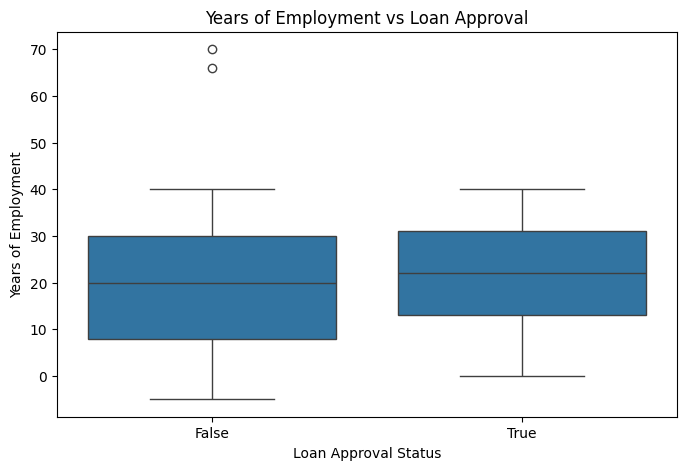

In [74]:
# Relationship between Years of Employment and Loan Approval

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=target,
    y='years_employed',
    data=df
)

plt.title("Years of Employment vs Loan Approval")
plt.xlabel("Loan Approval Status")
plt.ylabel("Years of Employment")

plt.show()

In [75]:
# Analyze Years of Employment according to loan approval status

employment_analysis = df.groupby(target)['years_employed'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

print("Years of Employment Analysis:")
display(employment_analysis)

Years of Employment Analysis:


,count,mean,median,min,max
loan_approved,,,,,
False,1121,19.425513,20.0,-5,70
True,879,21.829352,22.0,0,40


Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.

b) Treat outliers using capping techniques

**ANS:**

In [76]:
# Outlier Detection and Treatment

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points']


In [77]:
# Remove target variable from outlier treatment

target = 'LoanApproved'  # Replace with your actual target column name

outlier_cols = [col for col in numerical_cols if col != target]

print("Columns Selected for Outlier Detection:")
print(outlier_cols)

Columns Selected for Outlier Detection:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points']


In [78]:
# Detect outliers using IQR method

outlier_summary = []

for column in outlier_cols:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Column': column,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': len(outliers)
    })

# Convert results into DataFrame
outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Column,Lower Bound,Upper Bound,Number of Outliers
0,income,-26909.000,208305.000,0
1,credit_score,8.500,1140.500,3
2,loan_amount,-24198.875,74328.125,0
3,years_employed,-21.500,62.500,2
4,points,7.500,107.500,0


In [79]:
# Treat outliers using IQR Capping

for column in outlier_cols:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping
    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier capping completed successfully!")

Outlier capping completed successfully!


In [80]:
# Verify outliers after capping

outliers_after = []

for column in outlier_cols:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outliers_after.append({
        'Column': column,
        'Outliers After Capping': count
    })

outliers_after_df = pd.DataFrame(outliers_after)

display(outliers_after_df)

,Column,Outliers After Capping
0,income,0
1,credit_score,0
2,loan_amount,0
3,years_employed,0
4,points,0


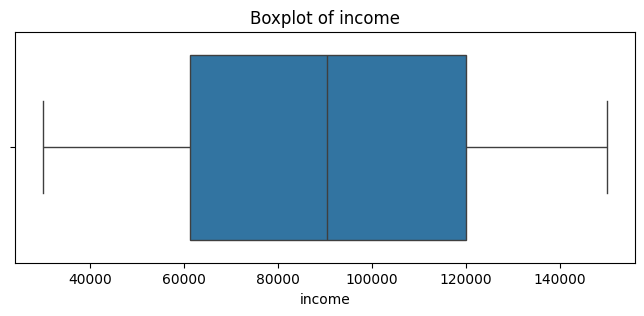

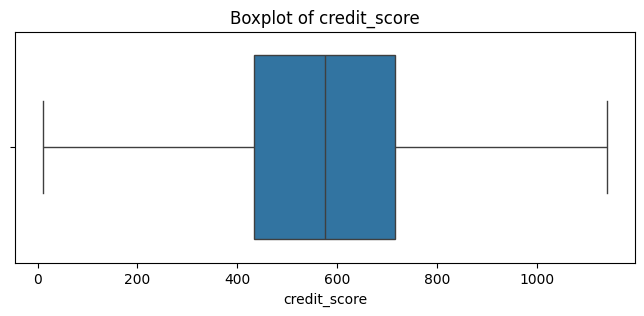

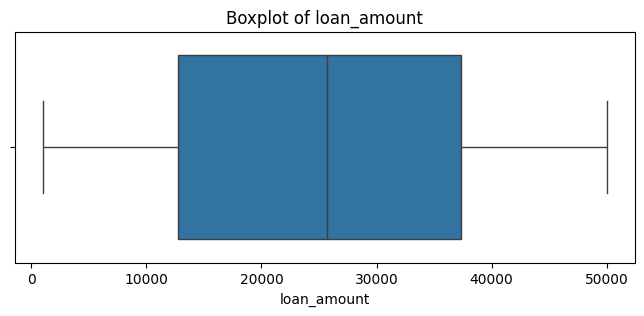

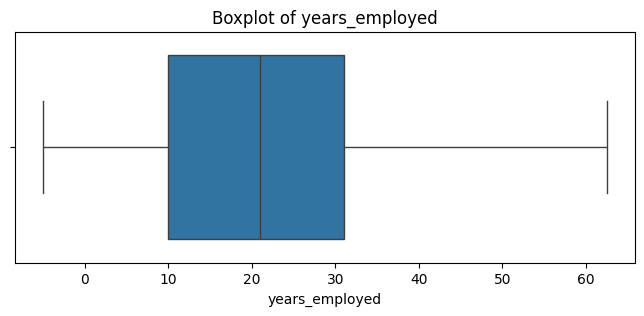

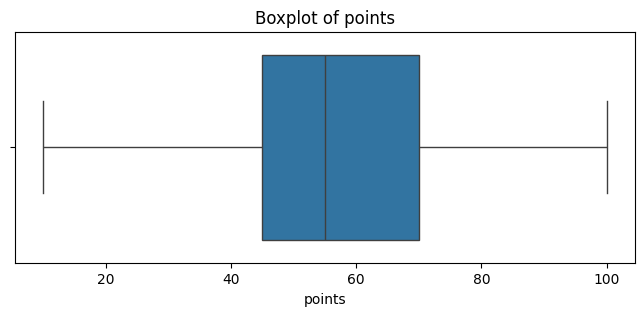

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in outlier_cols:

    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
columns.

In [82]:
# Check unique values in the target column

print("Unique values in Target Variable:")
print(df['loan_approved'].unique())

Unique values in Target Variable:
[False  True]


In [83]:
# Convert target variable into numerical format

df['LoanApproved'] = df['loan_approved'].map({
    'Yes': 1,
    'No': 0
})

print("Target variable converted successfully!")

print("\nUnique values after conversion:")
print(df['loan_approved'].unique())

Target variable converted successfully!

Unique values after conversion:
[False  True]


In [84]:
df['loan_approved'] = df['loan_approved'].map({
    'Approved': 1,
    'Rejected': 0
})

In [85]:
# Display column names

print("Columns in Dataset:")
print(df.columns.tolist())

Columns in Dataset:
['name', 'city', 'income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved', 'LoanApproved']


In [86]:
# Check dataset after preprocessing

print("Dataset Shape:", df.shape)

print("\nRemaining Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

display(df.head())

Dataset Shape: (2000, 9)

Remaining Columns:
['name', 'city', 'income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved', 'LoanApproved']

Data Types:
name               object
city               object
income              int64
credit_score      float64
loan_amount         int64
years_employed    float64
points              int64
loan_approved     float64
LoanApproved      float64
dtype: object


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved,LoanApproved
0,Allison Hill,East Jill,113810,389.0,39698,27.0,50,NaN,NaN
1,Brandon Hall,New Jamesside,44592,729.0,15446,28.0,55,NaN,NaN
2,Rhonda Smith,Lake Roberto,33278,584.0,11189,13.0,45,NaN,NaN
3,Gabrielle Davis,West Melanieview,127196,344.0,48823,29.0,50,NaN,NaN
4,Valerie Gray,Mariastad,66048,496.0,47174,4.0,25,NaN,NaN


Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y).

b) Split the dataset into training and testing sets.

**ANS:**

In [87]:
# Separate independent variables and dependent variable

# Target column
target = 'loan_approved'   # Replace with your exact target column name if different

# Independent variables
X = df.drop(columns=[target])

# Dependent variable
y = df[target]

print("Independent Variables (X):")
display(X.head())

print("\nDependent Variable (y):")
display(y.head())

Independent Variables (X):


,name,city,income,credit_score,loan_amount,years_employed,points,LoanApproved
0,Allison Hill,East Jill,113810,389.0,39698,27.0,50,NaN
1,Brandon Hall,New Jamesside,44592,729.0,15446,28.0,55,NaN
2,Rhonda Smith,Lake Roberto,33278,584.0,11189,13.0,45,NaN
3,Gabrielle Davis,West Melanieview,127196,344.0,48823,29.0,50,NaN
4,Valerie Gray,Mariastad,66048,496.0,47174,4.0,25,NaN



Dependent Variable (y):


,loan_approved
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [88]:
#Check Shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2000, 8)
Shape of y: (2000,)


In [89]:
# Check target values before splitting

print("Unique values in target:")
print(df['LoanApproved'].unique())

print("\nMissing values in target:")
print(df['LoanApproved'].isnull().sum())

print("\nTarget value counts:")
print(df['LoanApproved'].value_counts(dropna=False))

Unique values in target:
[nan]

Missing values in target:
2000

Target value counts:
LoanApproved
NaN    2000
Name: count, dtype: int64


In [90]:
print("Training Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Target Distribution:


NameError: name 'y_train' is not defined

Q7. Apply feature scaling to the dataset using StandardScaler.

In [ ]:
# Apply Feature Scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print ("Feature Scaling Completed Successfully!")

In [ ]:
# Convert scaled arrays back into DataFrames

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled Training Data:")
display(X_train_scaled.head())

In [ ]:
# Check mean and standard deviation after scaling

print("Mean of Scaled Training Features:")
print(X_train_scaled.mean().round(2))

print("\nStandard Deviation of Scaled Training Features:")
print(X_train_scaled.std(ddof=0).round(2))

Q8. Logistic Regression Model Building

a) Train a Logistic Regression model.

b) Predict the output for test data.

In [ ]:
# (a) Train a Logistic Regression Model

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model using scaled training data
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully!")

In [ ]:
# (b) Predict output for test data

y_pred = log_model.predict(X_test_scaled)

print("Prediction Completed Successfully!")

# Display first 20 predictions
print("\nFirst 20 Predicted Values:")
print(y_pred[:20])

In [ ]:
# Compare actual and predicted values

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

display(results.head(20))

In [ ]:
# Predict probabilities

y_prob = log_model.predict_proba(X_test_scaled)

probability_results = pd.DataFrame({
    'Probability_Not_Approved': y_prob[:, 0],
    'Probability_Approved': y_prob[:, 1],
    'Predicted_Class': y_pred
})

display(probability_results.head(10))

Q9. Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.

b) Interpret the results.

In [91]:
# (a) Generate Confusion Matrix

from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

NameError: name 'y_test' is not defined

In [92]:
# Visualize Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Approved (0)', 'Approved (1)'],
    yticklabels=['Not Approved (0)', 'Approved (1)']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

NameError: name 'cm' is not defined

<Figure size 700x500 with 0 Axes>

In [93]:
# Extract values from Confusion Matrix

TN, FP, FN, TP = cm.ravel()

print("True Negative  (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive  (TP):", TP)

NameError: name 'cm' is not defined

In [94]:
print("CONFUSION MATRIX INTERPRETATION")
print("--------------------------------")

print(f"True Negative (TN)  = {TN}")
print(f"{TN} loan applications were actually NOT approved and were correctly predicted as NOT approved.")

print(f"\nFalse Positive (FP) = {FP}")
print(f"{FP} loan applications were actually NOT approved but were incorrectly predicted as approved.")

print(f"\nFalse Negative (FN) = {FN}")
print(f"{FN} loan applications were actually approved but were incorrectly predicted as NOT approved.")

print(f"\nTrue Positive (TP)  = {TP}")
print(f"{TP} loan applications were actually approved and were correctly predicted as approved.")

print("\nTotal Correct Predictions:", TN + TP)
print("Total Incorrect Predictions:", FP + FN)

CONFUSION MATRIX INTERPRETATION
--------------------------------


NameError: name 'TN' is not defined

Q10. Model Evaluation – ROC Curve & AUC

a) Plot the ROC curve.
b) Calculate the AUC score

In [95]:
# ROC Curve and AUC Score

# Probability of positive class (Loan Approved = 1)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 Predicted Probabilities:")
print(y_prob[:10])

NameError: name 'X_test_scaled' is not defined

In [96]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate False Positive Rate, True Positive Rate and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print("ROC values calculated successfully!")

NameError: name 'y_test' is not defined

In [97]:
# Calculate AUC Score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", round(auc_score, 4))

NameError: name 'y_test' is not defined

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# ROC Curve
plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_score:.3f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()

plt.show()


NameError: name 'fpr' is not defined

<Figure size 800x600 with 0 Axes>

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# ROC Curve
plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_score:.3f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()

plt.show()

NameError: name 'fpr' is not defined

<Figure size 800x600 with 0 Axes>